# 1. Problem Statement
🔄 Customer Churn Prediction

🎯 Objective
The goal of this notebook is to build a machine learning classification model to predict customer churn, identifying whether a customer is likely to cancel or retain their subscription/service based on usage patterns, account demographics, and service interactions.

📌 Dataset Overview
We will use a cleaned dataset and focus on preprocessing, feature handling, class imbalance management, feature engineering, and modeling.

# 2. Import Libiraries

In [ ]:
import pandas as pd
import numpy as np
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.model_selection import GridSearchCV , RandomizedSearchCV ,cross_val_score , cross_validate, train_test_split, KFold, cross_val_predict
from sklearn.metrics import precision_recall_curve, classification_report, confusion_matrix, f1_score, recall_score, precision_score, accuracy_score, roc_auc_score
from sklearn.ensemble import VotingClassifier
import timeit
import os
from pathlib import Path
import joblib
from sklearn.base import clone


# 3. Load Data

In [2]:
# Determining the data path
BASE_DIR = Path.cwd()
while not (BASE_DIR / "dataset").exists():
    BASE_DIR = BASE_DIR.parent
data_path = BASE_DIR / "dataset" / "clean_Telco_Customer_Churn.csv"

df = pd.read_csv(data_path)
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# 4. Quick Exploration

In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7021 entries, 0 to 7020
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7021 non-null   object 
 1   SeniorCitizen     7021 non-null   int64  
 2   Partner           7021 non-null   object 
 3   Dependents        7021 non-null   object 
 4   tenure            7021 non-null   int64  
 5   PhoneService      7021 non-null   object 
 6   MultipleLines     7021 non-null   object 
 7   InternetService   7021 non-null   object 
 8   OnlineSecurity    7021 non-null   object 
 9   OnlineBackup      7021 non-null   object 
 10  DeviceProtection  7021 non-null   object 
 11  TechSupport       7021 non-null   object 
 12  StreamingTV       7021 non-null   object 
 13  StreamingMovies   7021 non-null   object 
 14  Contract          7021 non-null   object 
 15  PaperlessBilling  7021 non-null   object 
 16  PaymentMethod     7021 non-null   object 


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7021.000000,7021.000000,7021.000000,7021.000000
mean,0.162512,32.469449,64.851894,2286.765026
std,0.368947,24.534965,30.069001,2266.855057
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.750000,403.350000
50%,0.000000,29.000000,70.400000,1400.550000
75%,0.000000,55.000000,89.900000,3801.700000
max,1.000000,72.000000,118.750000,8684.800000


In [35]:
df.shape

(7021, 20)

# 5. Train Test Split

In [4]:
# spliting the features and target
X = df.drop(columns=["Churn"])
y = df["Churn"]

# split training and test data
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# 6. Preprocessing Pipeline

In [5]:
## Categorical Cardinality Analysis
cat_cols = df.select_dtypes(include="O")
for col in cat_cols.columns:
    print(f"{col} : {df[col].nunique()}")
    print("_"*50)

gender : 2
__________________________________________________
Partner : 2
__________________________________________________
Dependents : 2
__________________________________________________
PhoneService : 2
__________________________________________________
MultipleLines : 3
__________________________________________________
InternetService : 3
__________________________________________________
OnlineSecurity : 3
__________________________________________________
OnlineBackup : 3
__________________________________________________
DeviceProtection : 3
__________________________________________________
TechSupport : 3
__________________________________________________
StreamingTV : 3
__________________________________________________
StreamingMovies : 3
__________________________________________________
Contract : 3
__________________________________________________
PaperlessBilling : 2
__________________________________________________
PaymentMethod : 4
________________________________

## Encoding

#### 1. Encoding of target column

In [6]:
target_map = {"No": 0, "Yes": 1}
y_train = y_train.map(target_map)
y_test = y_test.map(target_map)

#### Encoding of categorical features

In [7]:
# identifying columns with object data type
ignored = ['Contract', 'Churn']
onehot_cols = [col for col in df.select_dtypes(include="object").columns if col not in ignored]
ordinal_cols = ['Contract']
contract_order = ["Month-to-month", "One year", "Two year"]
numerical_cols = ["tenure","MonthlyCharges","TotalCharges"]

preprocessor = ColumnTransformer(
    transformers=[
        ("scaler", StandardScaler(), numerical_cols),
        ("onehot", OneHotEncoder(sparse_output=False, handle_unknown="ignore"), onehot_cols),
        ("ordinal", OrdinalEncoder(categories=[contract_order]), ordinal_cols)
    ],
    remainder="passthrough"
)
print("Processor is ready")

Processor is ready


# 7. Baseline Models (Default)

In [11]:
models = [
    ("LR", LogisticRegression(random_state=42)),
    ("DT", DecisionTreeClassifier(random_state=42)),
    ("RF", RandomForestClassifier(random_state=42)),
    ("XGB", XGBClassifier(random_state=42))
]

# 8. Train & Compare

In [12]:
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"  
}

all_results = []

for model_name, model in models:
    
    start = timeit.default_timer()
    pipe = ImbPipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    scores = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=5,
        scoring=scoring,
        return_train_score=True
    )
    
    stop = timeit.default_timer()
    
    
    result_dict = {
        "Model": model_name,
        "Train Accuracy": scores["train_accuracy"].mean(),
        "Test Accuracy": scores["test_accuracy"].mean(),
        "Test Precision": scores["test_precision"].mean(),
        "Test Recall": scores["test_recall"].mean(),
        "Test F1": scores["test_f1"].mean(),
        "Test ROC-AUC": scores["test_roc_auc"].mean(),
        "Time (sec)": stop - start
    }
    
    all_results.append(result_dict)


df_results = pd.DataFrame(all_results)
df_results = df_results.sort_values(by="Test F1", ascending=False)

df_results

,Model,Train Accuracy,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC-AUC,Time (sec)
0,LR,0.807826,0.806978,0.667881,0.556811,0.607237,0.844101,0.600370
3,XGB,0.956330,0.780091,0.603730,0.522259,0.559914,0.824948,1.095269
2,RF,0.997819,0.784010,0.626688,0.479734,0.543399,0.819806,2.693477
1,DT,0.997952,0.729879,0.497176,0.514286,0.505028,0.662610,0.499535


# 9. Experiments

In [13]:
# =========================
# Collect All Results
# =========================
results = []

def add_result(name, train_accuracy, test_accuracy, test_precision, test_recall, test_f1, test_roc_auc):
    results.append({
        "Model": name,
        "Train Accuracy": train_accuracy,
        "Test Accuracy": test_accuracy,
        "Test Precision": test_precision,
        "Test Recall": test_recall,
        "Test F1": test_f1,
        "Test ROC-AUC": test_roc_auc
    })

### 🧪 Experiment 1: Baseline Models with Handling Imbalance via Data Level (Using SMOTE)

In [14]:
all_results = []

for model_name, model in models:
    start = timeit.default_timer()

    xgb_pipe = ImbPipeline(steps=[
        ("preprocessor", preprocessor),
        ("smote", SMOTE(random_state=42)),
        ("model", model)
    ])

    scores = cross_validate(
        xgb_pipe,
        X_train,
        y_train,
        cv=5,
        scoring=scoring,
        return_train_score=True
    )
    stop = timeit.default_timer()
        
    result_dict = {
        "Model": f"{model_name} + SMOTE", 
        "Train Accuracy": scores["train_accuracy"].mean(),
        "Test Accuracy": scores["test_accuracy"].mean(),
        "Test Precision": scores["test_precision"].mean(),
        "Test Recall": scores["test_recall"].mean(), 
        "Test F1": scores["test_f1"].mean(),
        "Test ROC-AUC": scores["test_roc_auc"].mean(),
        "Time (sec)": stop - start
    }
    all_results.append(result_dict)

df_results_smote = pd.DataFrame(all_results)
df_results_smote = df_results_smote.sort_values(by="Test Recall", ascending=False)

df_results_smote

,Model,Train Accuracy,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC-AUC,Time (sec)
0,LR + SMOTE,0.756365,0.754094,0.527519,0.794020,0.633828,0.843690,6.619535
3,XGB + SMOTE,0.940660,0.778311,0.589637,0.569435,0.579303,0.823859,2.065701
1,DT + SMOTE,0.997952,0.725425,0.490017,0.564120,0.524200,0.675125,0.782020
2,RF + SMOTE,0.997908,0.778308,0.593558,0.552824,0.572291,0.817230,5.585970


###  🧪 Experiment 2: Handling Imbalance via Algorithm Level (Using scale_pos_weight for XGBoost)

In [15]:
from sklearn.pipeline import Pipeline

scale_pos = (y_train == 0).sum() / (y_train == 1).sum()

xgb_weighted_pipe = ImbPipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(scale_pos_weight=scale_pos, random_state=42))
])

start = timeit.default_timer()

scores = cross_validate(
    xgb_weighted_pipe,
    X_train,
    y_train,
    cv=5,
    scoring=scoring,
    return_train_score=True
)

stop = timeit.default_timer()

xgb_weighted_result = {
    "Model": "XGB + scale_pos_weight",
    "Train Accuracy": scores["train_accuracy"].mean(),
    "Test Accuracy": scores["test_accuracy"].mean(),
    "Test Precision": scores["test_precision"].mean(),
    "Test Recall": scores["test_recall"].mean(), 
    "Test F1": scores["test_f1"].mean(),
    "Test ROC-AUC": scores["test_roc_auc"].mean(),
    "Time (sec)": stop - start
}

df_xgb_weighted = pd.DataFrame([xgb_weighted_result])
df_xgb_weighted

,Model,Train Accuracy,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC-AUC,Time (sec)
0,XGB + scale_pos_weight,0.947293,0.764421,0.550984,0.653156,0.5976,0.823297,1.164916


# 10. Hyperparameter Tuning

## 10.1 Logistic Regression + SMOTE

In [18]:
from sklearn.model_selection import GridSearchCV

lr_pipe = ImbPipeline(steps=[
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

param_grid_lr = {
    "smote__k_neighbors": [3, 5, 7],
    "model__C": [0.01, 0.1, 1.0, 10.0],
    "model__solver": ["lbfgs", "liblinear"]
}

grid_lr = GridSearchCV(
    estimator=lr_pipe,
    param_grid=param_grid_lr,
    cv=5,
    scoring=scoring,      
    refit="recall",       
    n_jobs=-1,
    return_train_score=True
)

grid_lr.fit(X_train, y_train)

best_idx_lr = grid_lr.best_index_
cv_res_lr = grid_lr.cv_results_

print("Best LR Params:", grid_lr.best_params_)
print(f"🔥Best LR Recall Score: {cv_res_lr['mean_test_recall'][best_idx_lr]:.4f}")
print("-" * 50)
print(f"🔹 Train Recall    : {cv_res_lr['mean_train_recall'][best_idx_lr]:.4f}")
print(f"🔹 Test Recall     : {cv_res_lr['mean_test_recall'][best_idx_lr]:.4f}")
print("-" * 50)
print(f"Train Precision    : {cv_res_lr['mean_train_precision'][best_idx_lr]:.4f}")
print(f"Test Precision     : {cv_res_lr['mean_test_precision'][best_idx_lr]:.4f}")
print("-" * 50)
print(f"Train F1-Score     : {cv_res_lr['mean_train_f1'][best_idx_lr]:.4f}")
print(f"Test F1-Score      : {cv_res_lr['mean_test_f1'][best_idx_lr]:.4f}")
print("-" * 50)
print(f"Train ROC-AUC      : {cv_res_lr['mean_train_roc_auc'][best_idx_lr]:.4f}")
print(f"Test ROC-AUC       : {cv_res_lr['mean_test_roc_auc'][best_idx_lr]:.4f}")
print("-" * 50)
print(f"Train Accuracy     : {cv_res_lr['mean_train_accuracy'][best_idx_lr]:.4f}")
print(f"Test Accuracy      : {cv_res_lr['mean_test_accuracy'][best_idx_lr]:.4f}")

Best LR Params: {'model__C': 10.0, 'model__solver': 'liblinear', 'smote__k_neighbors': 5}
🔥Best LR Recall Score: 0.7947
--------------------------------------------------
🔹 Train Recall    : 0.7978
🔹 Test Recall     : 0.7947
--------------------------------------------------
Train Precision    : 0.5306
Test Precision     : 0.5266
--------------------------------------------------
Train F1-Score     : 0.6373
Test F1-Score      : 0.6334
--------------------------------------------------
Train ROC-AUC      : 0.8482
Test ROC-AUC       : 0.8437
--------------------------------------------------
Train Accuracy     : 0.7566
Test Accuracy      : 0.7534


## 10.2 XGBoost

### 10.2.1 XGBoost Hyperparameter Tuning — Balanced Model

In [28]:
param_grid_xgb_balanced = {
    "model__n_estimators": [100, 150],
    "model__max_depth": [3, 4, 5],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__scale_pos_weight": [1.5, 2.0, 2.5, 3.0],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0]
}

grid_xgb_balanced = GridSearchCV(
    estimator=xgb_pipe,
    param_grid=param_grid_xgb_balanced,
    cv=5,
    scoring=scoring,
    refit="f1",  
    n_jobs=-1,
    return_train_score=True
)

grid_xgb_balanced.fit(X_train, y_train)

best_idx_xgb = grid_xgb_balanced.best_index_
cv_res_xgb = grid_xgb_balanced.cv_results_

print("Best XGB Params:", grid_xgb_balanced.best_params_)
print(f"🔥Best XGB F1 Score: {cv_res_xgb['mean_test_f1'][best_idx_xgb]:.4f}")
print("-" * 50)
print(f"🔹 Train Recall     : {cv_res_xgb['mean_train_recall'][best_idx_xgb]:.4f}")
print(f"🔹 Test Recall      : {cv_res_xgb['mean_test_recall'][best_idx_xgb]:.4f}")
print("-" * 50)
print(f"Train Precision     : {cv_res_xgb['mean_train_precision'][best_idx_xgb]:.4f}")
print(f"Test Precision      : {cv_res_xgb['mean_test_precision'][best_idx_xgb]:.4f}")
print("-" * 50)
print(f"Train F1-Score      : {cv_res_xgb['mean_train_f1'][best_idx_xgb]:.4f}")
print(f"Test F1-Score       : {cv_res_xgb['mean_test_f1'][best_idx_xgb]:.4f}")
print("-" * 50)
print(f"Train ROC-AUC       : {cv_res_xgb['mean_train_roc_auc'][best_idx_xgb]:.4f}")
print(f"Test ROC-AUC        : {cv_res_xgb['mean_test_roc_auc'][best_idx_xgb]:.4f}")
print("-" * 50)
print(f"Train Accuracy      : {cv_res_xgb['mean_train_accuracy'][best_idx_xgb]:.4f}")
print(f"Test Accuracy       : {cv_res_xgb['mean_test_accuracy'][best_idx_xgb]:.4f}")

Best XGB Params: {'model__colsample_bytree': 1.0, 'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 100, 'model__scale_pos_weight': 2.0, 'model__subsample': 0.8}
🔥Best XGB F1 Score: 0.5829
--------------------------------------------------
🔹 Train Recall     : 0.9279
🔹 Test Recall      : 0.9203
--------------------------------------------------
Train Precision     : 0.4281
Test Precision      : 0.4265
--------------------------------------------------
Train F1-Score      : 0.5858
Test F1-Score       : 0.5829
--------------------------------------------------
Train ROC-AUC       : 0.8493
Test ROC-AUC        : 0.8409
--------------------------------------------------
Train Accuracy      : 0.6481
Test Accuracy       : 0.6471


## 10.3 Random Forest Hyperparameter Tuning with SMOTE

In [21]:
rf_pipe = ImbPipeline(steps=[
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", RandomForestClassifier(random_state=42))
])

param_grid_rf = {
    "smote__k_neighbors": [3, 5],
    "model__n_estimators": [100, 200],
    "model__max_depth": [5, 8, 12],                
    "model__min_samples_split": [2, 5, 10],        
    "model__class_weight": ["balanced", "balanced_subsample", None] 
}

grid_rf = GridSearchCV(
    estimator=rf_pipe,
    param_grid=param_grid_rf,
    cv=5,
    scoring=scoring,
    refit="f1",   
    n_jobs=-1,
    return_train_score=True
)

grid_rf.fit(X_train, y_train)

best_idx_rf = grid_rf.best_index_
cv_res_rf = grid_rf.cv_results_

best_idx_rf = grid_rf.best_index_
cv_res_rf = grid_rf.cv_results_

print("Best RF Params:", grid_rf.best_params_)
print(f"🔥Best RF F1 Score: {cv_res_rf['mean_test_f1'][best_idx_rf]:.4f}")
print("-" * 50)
print(f"🔹 Train Recall     : {cv_res_rf['mean_train_recall'][best_idx_rf]:.4f}")
print(f"🔹 Test Recall      : {cv_res_rf['mean_test_recall'][best_idx_rf]:.4f}")
print("-" * 50)
print(f"Train Precision     : {cv_res_rf['mean_train_precision'][best_idx_rf]:.4f}")
print(f"Test Precision      : {cv_res_rf['mean_test_precision'][best_idx_rf]:.4f}")
print("-" * 50)
print(f"Train F1-Score      : {cv_res_rf['mean_train_f1'][best_idx_rf]:.4f}")
print(f"Test F1-Score       : {cv_res_rf['mean_test_f1'][best_idx_rf]:.4f}")
print("-" * 50)
print(f"Train ROC-AUC       : {cv_res_rf['mean_train_roc_auc'][best_idx_rf]:.4f}")
print(f"Test ROC-AUC        : {cv_res_rf['mean_test_roc_auc'][best_idx_rf]:.4f}")
print("-" * 50)
print(f"Train Accuracy      : {cv_res_rf['mean_train_accuracy'][best_idx_rf]:.4f}")
print(f"Test Accuracy       : {cv_res_rf['mean_test_accuracy'][best_idx_rf]:.4f}")

Best RF Params: {'model__class_weight': None, 'model__max_depth': 8, 'model__min_samples_split': 5, 'model__n_estimators': 100, 'smote__k_neighbors': 5}
--------------------------------------------------
🔹 Test Accuracy   : 0.7845
🔹 Test Precision  : 0.5808
🔹 Test Recall     : 0.7076
🔹 Test F1-Score   : 0.6378
🔹 Test ROC-AUC    : 0.8421


## 10.4 Voting Classifier (LR + RF + XGB)

In [24]:

pipe_lr_tuned = ImbPipeline(steps=[
    ("preprocessor", preprocessor),
    ("smote", SMOTE(k_neighbors=5, random_state=42)),
    ("model", LogisticRegression(C=10.0, solver="liblinear", random_state=42))
])

pipe_xgb_tuned = ImbPipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.05,
        scale_pos_weight=2.0,
        subsample=0.8,
        colsample_bytree=1.0,
        random_state=42
    ))
])

pipe_rf_tuned = ImbPipeline(steps=[
    ("preprocessor", preprocessor),
    ("smote", SMOTE(k_neighbors=5, random_state=42)),
    ("model", RandomForestClassifier(
        n_estimators=100,
        max_depth=8,
        min_samples_split=5,
        class_weight=None,
        random_state=42
    ))
])

voting_clf = VotingClassifier(
    estimators=[
        ('lr', pipe_lr_tuned),
        ('xgb', pipe_xgb_tuned),
        ('rf', pipe_rf_tuned)
    ],
    voting='soft'  
)

start = timeit.default_timer()

voting_cv_results = cross_validate(
    voting_clf,
    X_train,
    y_train,
    cv=5,
    scoring=scoring,
    return_train_score=True,
    n_jobs=-1
)

stop = timeit.default_timer()

print("🔥 Soft Voting Classifier Results (5-Fold CV):")
print("-" * 50)
print(f"🔹 Train Accuracy   : {voting_cv_results['train_accuracy'].mean():.4f}")
print(f"🔹 Test Accuracy   : {voting_cv_results['test_accuracy'].mean():.4f}")
print("-" * 50)
print(f"🔹 Train Precision  : {voting_cv_results['train_precision'].mean():.4f}")
print(f"🔹 Test Precision  : {voting_cv_results['test_precision'].mean():.4f}")
print("-" * 50)
print(f"🔹 Train Recall     : {voting_cv_results['train_recall'].mean():.4f}")
print(f"🔹 Test Recall     : {voting_cv_results['test_recall'].mean():.4f}")
print("-" * 50)
print(f"🔹 Train F1-Score   : {voting_cv_results['train_f1'].mean():.4f}")
print(f"🔹 Test F1-Score   : {voting_cv_results['test_f1'].mean():.4f}")
print("-" * 50)
print(f"🔹 Train ROC-AUC    : {voting_cv_results['train_roc_auc'].mean():.4f}")
print(f"🔹 Test ROC-AUC    : {voting_cv_results['test_roc_auc'].mean():.4f}")
print(f"⏱️ Execution Time  : {stop - start:.2f} seconds")

🔥 Soft Voting Classifier Results (5-Fold CV):
--------------------------------------------------
🔹 Train Accuracy   : 0.7958
🔹 Test Accuracy   : 0.7728
--------------------------------------------------
🔹 Train Precision  : 0.5895
🔹 Test Precision  : 0.5571
--------------------------------------------------
🔹 Train Recall     : 0.7839
🔹 Test Recall     : 0.7468
--------------------------------------------------
🔹 Train F1-Score   : 0.6729
🔹 Test F1-Score   : 0.6380
--------------------------------------------------
🔹 Train ROC-AUC    : 0.8763
🔹 Test ROC-AUC    : 0.8490
⏱️ Execution Time  : 1.77 seconds


## 11. XGBoost Threshold Tuning and Final Evaluation

In [25]:
best_xgb_model = ImbPipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.05,
        scale_pos_weight=2.0,
        subsample=0.8,
        colsample_bytree=1.0,
        random_state=42
    ))
])

y_probs = cross_val_predict(best_xgb_model, X_train, y_train, cv=5, method="predict_proba")[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_train, y_probs)

f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_threshold_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_threshold_idx]

print(f"🎯 Optimal Threshold for Max F1-Score: {best_threshold:.4f}")
print(f"🔹 Expected Recall at Optimal Threshold : {recalls[best_threshold_idx]:.4f}")
print(f"🔹 Expected Precision at Optimal Threshold: {precisions[best_threshold_idx]:.4f}")
print(f"🔹 Expected F1-Score at Optimal Threshold : {f1_scores[best_threshold_idx]:.4f}")

🎯 Optimal Threshold for Max F1-Score: 0.5314
🔹 Expected Recall at Optimal Threshold : 0.6950
🔹 Expected Precision at Optimal Threshold: 0.5960
🔹 Expected F1-Score at Optimal Threshold : 0.6417


In [26]:
print("Thresh  | Recall  | Precision | F1-Score | Accuracy")
print("-" * 52)

for th in [0.35, 0.40, 0.45, 0.50, 0.5314]:
    y_pred_th = (y_probs >= th).astype(int)
    rec = recall_score(y_train, y_pred_th)
    prec = precision_score(y_train, y_pred_th)
    f1 = f1_score(y_train, y_pred_th)
    acc = accuracy_score(y_train, y_pred_th)
    print(f"{th:.4f}  | {rec:.4f} |  {prec:.4f}   |  {f1:.4f}  |  {acc:.4f}")

Thresh  | Recall  | Precision | F1-Score | Accuracy
----------------------------------------------------
0.3500  | 0.8605 |  0.4905   |  0.6248  |  0.7231
0.4000  | 0.8279 |  0.5138   |  0.6341  |  0.7439
0.4500  | 0.7801 |  0.5385   |  0.6372  |  0.7619
0.5000  | 0.7256 |  0.5702   |  0.6386  |  0.7799
0.5314  | 0.6950 |  0.5960   |  0.6417  |  0.7920


🔥 FINAL TEST SET EVALUATION (Threshold = 0.45):
              precision    recall  f1-score   support

           0     0.9082    0.7331    0.8114      1053
           1     0.4937    0.7784    0.6042       352

    accuracy                         0.7445      1405
   macro avg     0.7010    0.7558    0.7078      1405
weighted avg     0.8044    0.7445    0.7594      1405

🔹 Test ROC-AUC Score: 0.8433


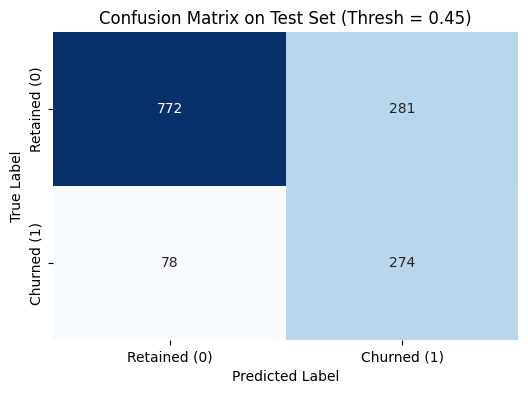

In [27]:

best_xgb_model.fit(X_train, y_train)

chosen_threshold = 0.45  

test_probs = best_xgb_model.predict_proba(X_test)[:, 1]
test_preds = (test_probs >= chosen_threshold).astype(int)

print(f"🔥 FINAL TEST SET EVALUATION (Threshold = {chosen_threshold}):")
print("=" * 60)
print(classification_report(y_test, test_preds, digits=4))
print(f"🔹 Test ROC-AUC Score: {roc_auc_score(y_test, test_probs):.4f}")
print("=" * 60)

# 4. رسم الـ Confusion Matrix بشكل شيك
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, test_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Retained (0)", "Churned (1)"],
            yticklabels=["Retained (0)", "Churned (1)"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title(f"Confusion Matrix on Test Set (Thresh = {chosen_threshold})")
plt.show()

## 🎯 Business-Oriented Model Selection

### Understanding the Business Problem

The goal of this project is not simply to maximize **accuracy**. In a Customer Churn Prediction problem, the business objective is to identify customers who are likely to leave the company **before they actually churn**, so that the company can take proactive retention actions.

From a business perspective, missing a customer who is actually going to churn (**False Negative**) can be more costly than incorrectly flagging a customer who decides to stay (**False Positive**).

Therefore, **Recall for the Churn class** is an important metric in this problem because it measures how many of the actual churners we are able to identify.

At the same time, maximizing Recall alone is not enough. A model with very high Recall may classify too many retained customers as potential churners, which can lead to unnecessary retention campaigns and increased business costs.

For this reason, I evaluated the models using multiple metrics, including:

- **Recall:** How many actual churners are detected.
- **Precision:** How many customers predicted as churners are actually churners.
- **F1-Score:** Balance between Precision and Recall.
- **ROC-AUC:** Overall ability of the model to distinguish between churners and retained customers.
- **Accuracy:** Overall classification correctness.

---

### 📊 Model Comparison

After evaluating several models, the results were:

| Model | Recall | Precision | F1-Score | ROC-AUC | Accuracy |
|---|---:|---:|---:|---:|---:|
| Logistic Regression + SMOTE | **79.47%** | 52.66% | 0.6334 | 0.8437 | 0.7534 |
| XGBoost + `scale_pos_weight` | 72.69% | **57.61%** | **0.6426** | **0.8507** | 0.7833 |
| Random Forest + SMOTE | 70.76% | 58.08% | 0.6378 | 0.8421 | 0.7845 |
| Soft Voting Classifier | 74.68% | 55.71% | 0.6380 | 0.8490 | 0.7728 |

Although Logistic Regression achieved the highest Recall, **XGBoost provided the best overall balance between the important evaluation metrics**.

It achieved the highest **F1-Score, Precision, and ROC-AUC**, while maintaining a strong Recall.

Therefore, I selected **XGBoost as the final model**.

---

### 🎚️ Threshold Tuning

The default classification threshold of `0.50` is not necessarily the optimal threshold for a business problem.

Since identifying potential churners is important, I experimented with different probability thresholds to understand the trade-off between **Recall and Precision**.

The results showed that lowering the threshold increases Recall, meaning that the model identifies more potential churners, but it also increases False Positives.

For example, at a threshold of `0.45`, the model prioritizes detecting more churners while maintaining a reasonable level of Precision.

This represents a business trade-off:

> **Lower threshold → More churners detected → More False Positives → More customers targeted for retention actions**

Therefore, the final threshold was selected based on the business objective rather than simply choosing the threshold that produces the highest Accuracy.

---

### 🏆 Final Model Decision

I selected:

**XGBoost + `scale_pos_weight` with a classification threshold of `0.45`**

The reason for this choice is that the objective of the system is to **proactively identify customers at risk of churn**, rather than simply maximize overall classification accuracy.

On the final test set, the model achieved:

| Metric | Test Result |
|---|---:|
| Recall (Churn) | **77.84%** |
| Precision (Churn) | **49.37%** |
| F1-Score (Churn) | **0.6042** |
| Accuracy | **74.45%** |
| ROC-AUC | **0.8433** |

At this threshold, the model correctly identified **274 out of 352 actual churners**, while missing **78 churners**.

This means the model can identify approximately **78% of the customers who actually churned**, which is valuable for a retention-focused business scenario.

However, the relatively lower Precision indicates that a significant number of customers predicted as potential churners are actually retained customers. These False Positives should not necessarily be considered a model failure; instead, their business impact depends on the **cost of the retention action**.

For example, if the company offers a low-cost retention campaign, accepting more False Positives may be reasonable in exchange for identifying more potential churners.

---

### 💡 Business Interpretation

The model should therefore be viewed as a **decision-support tool**, rather than simply a binary classifier.

The business can use the predicted churn probabilities to:

1. Identify customers with a high risk of churn.
2. Prioritize customers for retention campaigns.
3. Offer targeted incentives or personalized communication.
4. Allocate the retention budget toward customers with higher churn risk.
5. Monitor whether these interventions actually reduce churn.

Ultimately, the optimal threshold should depend on the **business cost of False Positives vs. False Negatives**.

If missing a churner is very expensive, the business may prefer a lower threshold and higher Recall.

If retention campaigns are expensive, the business may prefer a higher threshold and higher Precision.

Therefore, the final model and threshold were selected based on the **business objective and the trade-off between detecting churners and avoiding unnecessary interventions**, rather than relying on a single evaluation metric.